# Movie Review Sentiment Analysis

An NLP machine learning project that classifies movie reviews as positive or negative.

## Objective

Build a machine learning model that can understand the sentiment of text reviews and classify them as positive or negative.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [6]:
!pip install -q datasets

In [7]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

print("Dataset loaded successfully!")
print(dataset)

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset loaded successfully!
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [8]:
# Convert datasets to Pandas DataFrames

train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

train_df.head()

Training data shape: (25000, 2)
Testing data shape: (25000, 2)


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [9]:
# Check sentiment distribution

print(train_df["label"].value_counts())

print("\nSentiment percentages:")
print(train_df["label"].value_counts(normalize=True) * 100)

label
0    12500
1    12500
Name: count, dtype: int64

Sentiment percentages:
label
0    50.0
1    50.0
Name: proportion, dtype: float64


In [10]:
# Display sample reviews

print("Negative review:")
print(train_df[train_df["label"] == 0]["text"].iloc[0])

print("\n" + "=" * 80 + "\n")

print("Positive review:")
print(train_df[train_df["label"] == 1]["text"].iloc[0])


Negative review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and

In [11]:
import re

def clean_text(text):
    # Remove HTML tags
    text = re.sub(r"<br\s*/?>", " ", text)

    # Convert text to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [12]:
# Clean the review text

train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

print("Text cleaning completed!")

train_df[["text", "clean_text", "label"]].head()

Text cleaning completed!


,text,clean_text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,i rented i am curious yellow from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",i am curious yellow is a risible and pretentio...,0
2,If only to avoid making this type of film in t...,if only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,this film was probably inspired by godard s ma...,0
4,"Oh, brother...after hearing about this ridicul...",oh brother after hearing about this ridiculous...,0


In [13]:
# Separate text features and sentiment labels

X_train = train_df["clean_text"]
y_train = train_df["label"]

X_test = test_df["clean_text"]
y_test = test_df["label"]

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))
print("Training labels:", len(y_train))
print("Testing labels:", len(y_test))

Training reviews: 25000
Testing reviews: 25000
Training labels: 25000
Testing labels: 25000


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2
)

# Learn vocabulary from training data and transform it
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data using the same vocabulary
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF conversion completed!")
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

TF-IDF conversion completed!
Training TF-IDF shape: (25000, 20000)
Testing TF-IDF shape: (25000, 20000)


In [15]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


In [16]:
# Make predictions on the test data

y_pred = model.predict(X_test_tfidf)

print("Predictions completed!")
print("Number of predictions:", len(y_pred))

Predictions completed!
Number of predictions: 25000


In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"]
))

Test Accuracy: 0.8952

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.89      0.89     12500
    Positive       0.89      0.90      0.90     12500

    accuracy                           0.90     25000
   macro avg       0.90      0.90      0.90     25000
weighted avg       0.90      0.90      0.90     25000



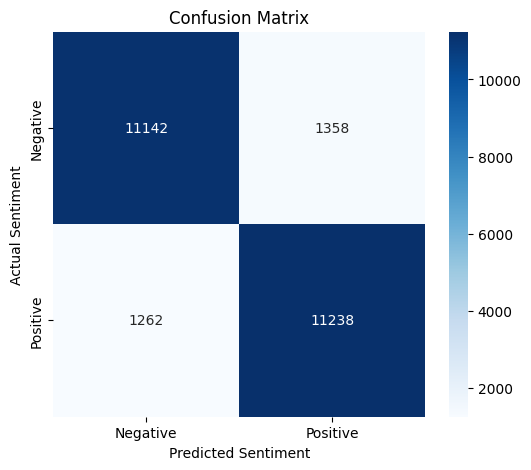

In [18]:
# Create confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Confusion Matrix")
plt.show()

In [19]:
# Test the model with a custom movie review

custom_review = """
This movie was absolutely fantastic. The story was engaging,
the acting was excellent, and I really enjoyed every minute of it.
"""

# Clean the review
cleaned_review = clean_text(custom_review)

# Convert the review into TF-IDF features
review_tfidf = tfidf.transform([cleaned_review])

# Make prediction
prediction = model.predict(review_tfidf)[0]

# Convert numerical prediction to sentiment
sentiment = "Positive" if prediction == 1 else "Negative"

print("Review:", custom_review.strip())
print("Predicted Sentiment:", sentiment)

Review: This movie was absolutely fantastic. The story was engaging,
the acting was excellent, and I really enjoyed every minute of it.
Predicted Sentiment: Positive


In [20]:
# Get prediction probability

probabilities = model.predict_proba(review_tfidf)[0]

negative_probability = probabilities[0]
positive_probability = probabilities[1]

print("Negative probability:", round(negative_probability * 100, 2), "%")
print("Positive probability:", round(positive_probability * 100, 2), "%")

Negative probability: 12.39 %
Positive probability: 87.61 %


In [21]:
import joblib

# Save the trained model
joblib.dump(model, "sentiment_model.pkl")

# Save the TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and TF-IDF vectorizer saved successfully!")

Model and TF-IDF vectorizer saved successfully!


In [22]:
import os

print("Saved files:")

for file in ["sentiment_model.pkl", "tfidf_vectorizer.pkl"]:
    print(file, "->", os.path.getsize(file), "bytes")

Saved files:
sentiment_model.pkl -> 160863 bytes
tfidf_vectorizer.pkl -> 765066 bytes


# Conclusion

This project developed an end-to-end Natural Language Processing (NLP) system for movie review sentiment classification.

## Results

- Dataset: IMDb Movie Reviews
- Training samples: 25,000
- Testing samples: 25,000
- Text representation: TF-IDF
- Maximum TF-IDF features: 20,000
- Model: Logistic Regression
- Test Accuracy: 89.52%
- Negative F1-score: 0.89
- Positive F1-score: 0.90

## Key Learning Outcomes

- Performed text preprocessing and cleaning
- Converted natural language into numerical features using TF-IDF
- Trained a Logistic Regression classifier for binary sentiment classification
- Evaluated the model using accuracy, precision, recall, F1-score, and a confusion matrix
- Tested the model on a custom movie review
- Generated prediction confidence scores
- Saved the trained model and TF-IDF vectorizer using Joblib

The final model successfully classifies movie reviews as positive or negative and achieves approximately 89.52% accuracy on unseen test data.